In [ ]:
import pandas as pd
import numpy as np
from wordcloud import WordCloud, STOPWORDS
import random
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
df=pd.read_csv("/content/sample_data/processed_ipl_data2.csv",low_memory=False)
df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,method,umpire1,umpire2,is_legal,legal_ball,all_balls_over_ball,adjusted_over_ball,match_number_of_that_season,matches_in_that_season,match_number_in_total
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,Normal,Asad Rauf,RE Koertzen,True,1.0,0.1,0.1,1.0,58.0,1.0
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,Normal,Asad Rauf,RE Koertzen,True,2.0,0.2,0.2,1.0,58.0,1.0
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,Normal,Asad Rauf,RE Koertzen,False,2.0,0.3,0.2,1.0,58.0,1.0
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,Normal,Asad Rauf,RE Koertzen,True,3.0,0.4,0.3,1.0,58.0,1.0
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,Normal,Asad Rauf,RE Koertzen,True,4.0,0.5,0.4,1.0,58.0,1.0


# New Section

In [ ]:
print("Shape:", df.shape)
print(df.info())


Shape: (38990, 44)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38990 entries, 0 to 38989
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   match_id                     38990 non-null  int64  
 1   inning                       38990 non-null  int64  
 2   batting_team                 38990 non-null  object 
 3   bowling_team                 38990 non-null  object 
 4   over                         38990 non-null  int64  
 5   ball                         38990 non-null  int64  
 6   batter                       38990 non-null  object 
 7   bowler                       38990 non-null  object 
 8   non_striker                  38990 non-null  object 
 9   batsman_runs                 38990 non-null  int64  
 10  extra_runs                   38990 non-null  int64  
 11  total_runs                   38990 non-null  int64  
 12  extras_type                  2377 non-null   object 
 1

In [ ]:
#df.drop(columns=["match_id"], inplace=True, errors="ignore")

In [ ]:
df["fielder"] = df["fielder"].fillna("NA")
df["extras_type"] = df["extras_type"].fillna("No Extra")
df["player_dismissed"] = df["player_dismissed"].fillna("Not Out")
df["dismissal_kind"] = df["dismissal_kind"].fillna("NA")
df["city"] = df["city"].fillna("Unknown")

In [ ]:
df["season"] = pd.to_numeric(df["season"], errors="coerce")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["result_margin"] = pd.to_numeric(df["result_margin"], errors="coerce")

/tmp/ipykernel_726/4149693685.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


In [ ]:
categorical_cols = ["super_over","match_type","toss_decision","result","method"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

In [ ]:

team_replace = {
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}

for col in ["batting_team","bowling_team","team1","team2","toss_winner","winner"]:
    df[col] = df[col].replace(team_replace)


In [ ]:
drop_cols = [
    "legal_ball",
    "all_balls_over_ball",
    "adjusted_over_ball",
    "match_number_of_that_season",
    "matches_in_that_season",
    "match_number_in_total"
]

df.drop(columns=drop_cols, inplace=True)

In [ ]:
df["run_rate"] = df["total_runs"] / (df["over"] + 1)

In [ ]:
df["is_boundary"] = df["batsman_runs"].apply(lambda x: 1 if x in [4,6] else 0)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr

    df = df[(df[col] >= lower) & (df[col] <= upper)]


In [ ]:
print("Cleaned Shape:", df.shape)
print(df.isnull().sum())

Cleaned Shape: (7952, 40)
match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batter              0
bowler              0
non_striker         0
batsman_runs        0
extra_runs          0
total_runs          0
extras_type         0
is_wicket           0
player_dismissed    0
dismissal_kind      0
fielder             0
id                  0
season              0
city                0
date                0
match_type          0
player_of_match     0
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              0
result              0
result_margin       0
target_runs         0
target_overs        0
super_over          0
method              0
umpire1             0
umpire2             0
is_legal            0
run_rate            0
is_boundary         0
dtype: int64


In [ ]:
df.to_csv("cleaned_ipl_dataset.csv", index=False)

print("Dataset cleaned and saved successfully!")

Dataset cleaned and saved successfully!


In [ ]:
df

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,is_legal,run_rate,is_boundary
13490,392181,1,Mumbai Indians,Chennai Super Kings,0,2,SR Tendulkar,MS Gony,ST Jayasuriya,0,...,19.0,166.0,20.0,N,Normal,BR Doctrove,K Hariharan,True,0.00,0
13491,392181,1,Mumbai Indians,Chennai Super Kings,0,3,SR Tendulkar,MS Gony,ST Jayasuriya,0,...,19.0,166.0,20.0,N,Normal,BR Doctrove,K Hariharan,True,0.00,0
13493,392181,1,Mumbai Indians,Chennai Super Kings,0,5,ST Jayasuriya,MS Gony,SR Tendulkar,0,...,19.0,166.0,20.0,N,Normal,BR Doctrove,K Hariharan,True,0.00,0
13496,392181,1,Mumbai Indians,Chennai Super Kings,1,2,SR Tendulkar,T Thushara,ST Jayasuriya,0,...,19.0,166.0,20.0,N,Normal,BR Doctrove,K Hariharan,True,0.00,0
13500,392181,1,Mumbai Indians,Chennai Super Kings,1,6,SR Tendulkar,T Thushara,ST Jayasuriya,0,...,19.0,166.0,20.0,N,Normal,BR Doctrove,K Hariharan,True,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27089,392239,2,Royal Challengers Bangalore,Deccan Chargers,19,1,A Kumble,RP Singh,RV Uthappa,1,...,6.0,144.0,20.0,N,Normal,RE Koertzen,SJA Taufel,True,0.05,0
27090,392239,2,Royal Challengers Bangalore,Deccan Chargers,19,2,RV Uthappa,RP Singh,A Kumble,0,...,6.0,144.0,20.0,N,Normal,RE Koertzen,SJA Taufel,True,0.00,0
27091,392239,2,Royal Challengers Bangalore,Deccan Chargers,19,3,RV Uthappa,RP Singh,A Kumble,0,...,6.0,144.0,20.0,N,Normal,RE Koertzen,SJA Taufel,True,0.00,0
27092,392239,2,Royal Challengers Bangalore,Deccan Chargers,19,4,RV Uthappa,RP Singh,A Kumble,2,...,6.0,144.0,20.0,N,Normal,RE Koertzen,SJA Taufel,True,0.10,0


In [ ]:
df.to_excel("output.xlsx", index=False)

In [ ]:
df.to_excel(r"C:\Users\YourName\Downloads\output.xlsx", index=False)

In [ ]:
df.to_csv("cleaned_ipl_dataset.csv", index=False)
df.to_excel("cleaned_ipl_dataset.xlsx", index=False)

print("Dataset cleaned and saved successfully!")

Dataset cleaned and saved successfully!


In [ ]:
text_data = " ".join(df["batter"].dropna().astype(str))

In [ ]:
stopwords = set(STOPWORDS)
stopwords.update(["the","and","is","in","to"])

In [ ]:
def random_color(*args, **kwargs):
    colors=["red","blue","green","purple","orange","grey","black"]
    return random.choice(colors)



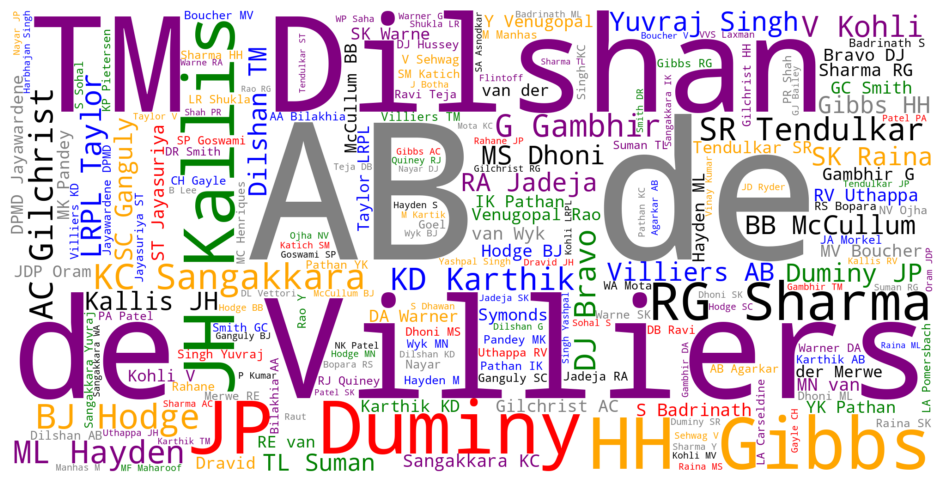

In [ ]:
wordcloud = WordCloud(
    width=2000,
    height=1000,
    background_color="white",
    stopwords=stopwords,
    color_func=random_color
).generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

wordcloud.to_file("wordcloud_basic.png")

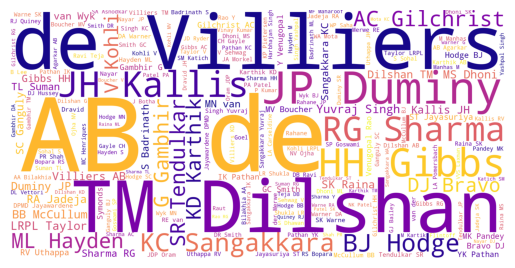

In [ ]:
wc = WordCloud(background_color="white", colormap="plasma", width=2000, height=1000).generate(text_data)
plt.imshow(wc)
plt.axis("off")
plt.show()

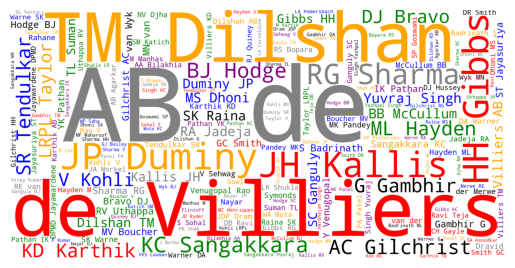

In [ ]:
def random_color(*args, **kwargs):
    colors=["red","blue","green","purple","orange","grey","black"]
    return random.choice(colors)

wc = WordCloud(background_color="white", color_func=random_color, width=2000, height=1000).generate(text_data)

plt.imshow(wc)
plt.axis("off")
plt.show()

Mask not found — using normal wordcloud


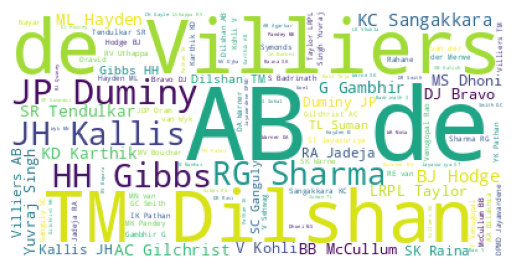

In [ ]:
import os

if os.path.exists("heart_mask.jpg"):
    mask_image = Image.open("heart_mask.jpg").convert("L")
    mask = np.array(mask_image)
    mask = np.where(mask > 128, 255, 0)

    wc = WordCloud(background_color="white", mask=mask, colormap="tab10").generate(text_data)
else:
    print("Mask not found — using normal wordcloud")
    wc = WordCloud(background_color="white").generate(text_data)

plt.imshow(wc)
plt.axis("off")
plt.show()

In [ ]:
def generate_wc(title, **kwargs):
    wc = WordCloud(
        width=2000,
        height=1000,
        stopwords=stopwords,
        background_color="white",
        **kwargs
    ).generate(text_data)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.show()

In [ ]:
def generate_wc(title, **kwargs):
    wc = WordCloud(
        width=2000,
        height=1000,
        stopwords=stopwords,
        **kwargs     # only kwargs here
    ).generate(text_data)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=15)
    plt.axis("off")
    plt.show()

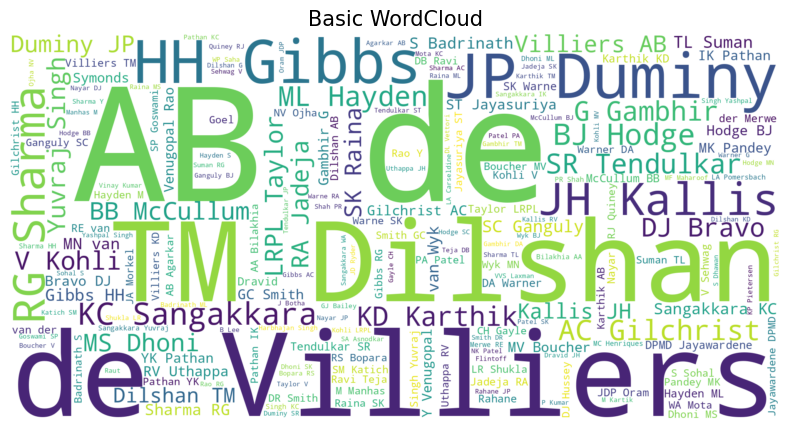

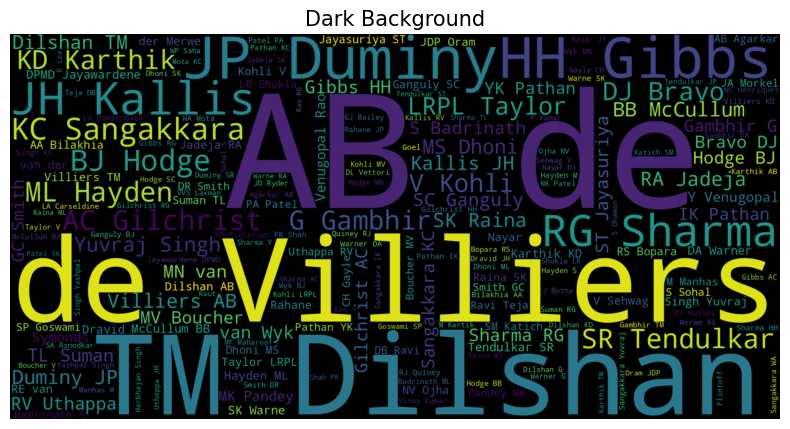

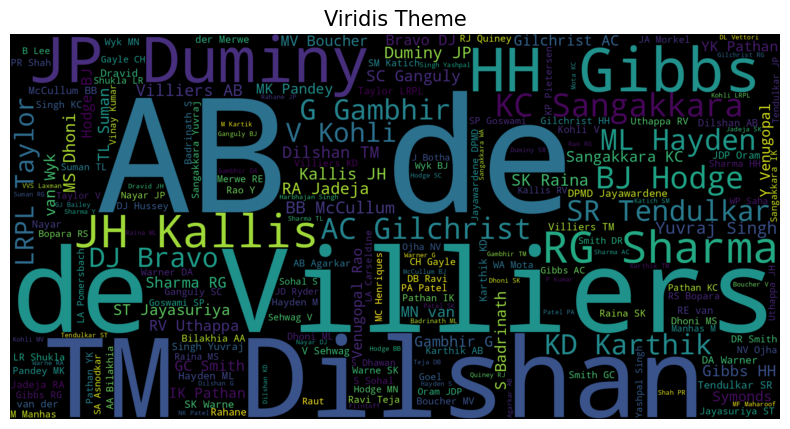

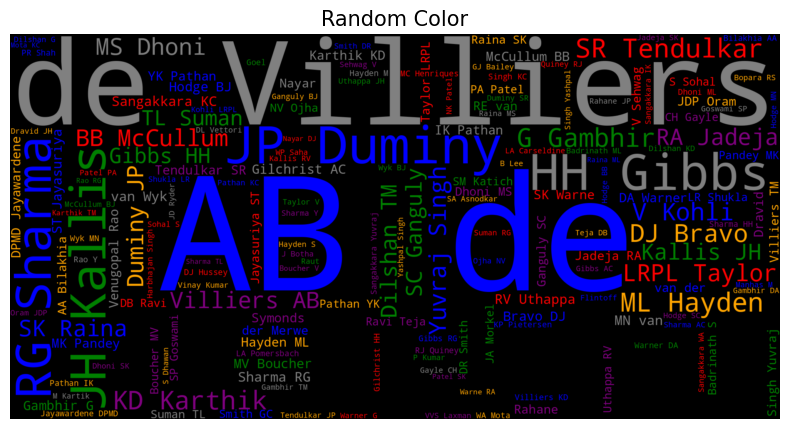

In [ ]:
generate_wc("Basic WordCloud", background_color="white")
generate_wc("Dark Background", background_color="black")
generate_wc("Viridis Theme", colormap="viridis")
generate_wc("Random Color", color_func=random_color)

In [ ]:
def generate_wc(title, background_color="white", **kwargs):
    wc = WordCloud(
        width=2000,
        height=1000,
        stopwords=stopwords,
        background_color=background_color,
        **kwargs
    ).generate(text_data)

In [ ]:
generate_wc(
    "Professional Cloud",
    background_color="black",
    colormap="viridis",
    contour_width=2,
    contour_color="white"
)

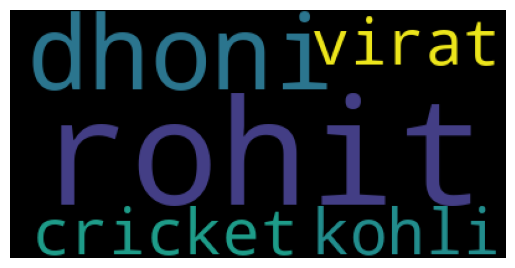

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = "cricket virat rohit dhoni kohli rohit dhoni dhoni rohit"

wc = WordCloud(background_color="black").generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

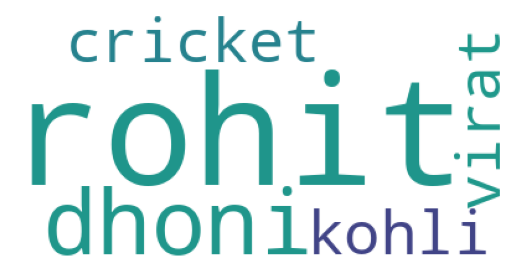

In [ ]:
wc = WordCloud(background_color="white", max_words=50, stopwords=stopwords).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

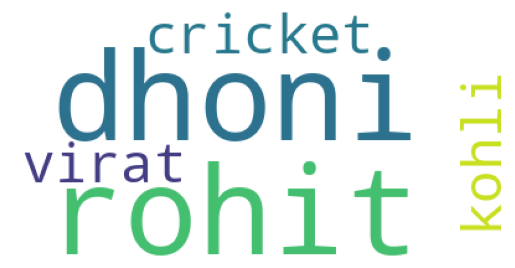

In [ ]:
wc = WordCloud(background_color="white", contour_width=2, contour_color="blue", stopwords=stopwords).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.show()

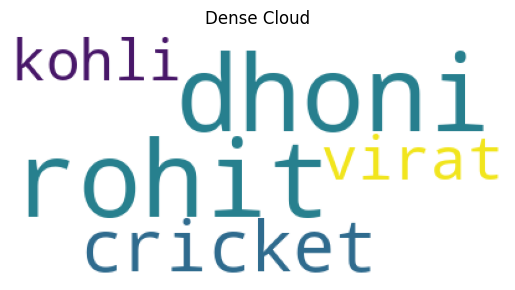

In [ ]:
wc = WordCloud(background_color="white", max_words=300, stopwords=stopwords).generate(text)
plt.imshow(wc); plt.axis("off"); plt.title("Dense Cloud"); plt.show()

In [ ]:
generate_wc("Basic WordCloud", background_color="white")

generate_wc("Dark Background", background_color="black")

generate_wc("Viridis Theme", colormap="viridis")

generate_wc("Plasma Theme", colormap="plasma")

generate_wc("Dense WordCloud", max_words=300)

generate_wc("Top Words", max_words=50)

generate_wc("Border Cloud", contour_width=2, contour_color="blue")

generate_wc("HD Cloud", scale=3)

generate_wc("Horizontal Words", prefer_horizontal=1.0)

generate_wc("Random Color", color_func=random_color)

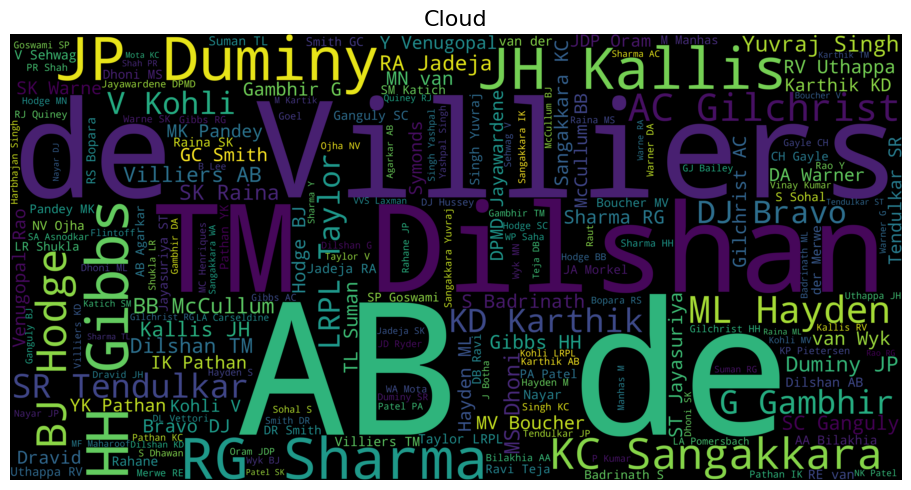

In [ ]:
def generate_wc(title, **kwargs):
    wc = WordCloud(
        width=2000,
        height=1000,
        stopwords=stopwords,
        **kwargs
    ).generate(text_data)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ---- run test ----
generate_wc(
    "Cloud",
    background_color="black",
    colormap="viridis",
    contour_width=2,
    contour_color="white",
    scale=3
)